# AM - KNN com Dataset do Scikit-learn

## Instruções
### Utilize o dataset breast_cancer do próprio scikit-learn (sklearn.datasets.load_breast_cancer()).

### Crie um notebook onde você demonstre:
- Informações gerais sobre o dataset (shape, classes e features)
- Ao menos um gráfico explorando a distribuição dos dados
- Pré-processamento com StandardScaler, justificando por que isso é necessário para o KNN
- Treinamento do modelo testando valores de K de 1 a 20
- Gráfico de acurácia × K e escolha justificada do melhor K
- classification_report do modelo final com o K escolhido

In [89]:
# Carregando o dataset breast_cancer do scikit-learn
from sklearn.datasets import load_breast_cancer

data_breast_cancer = load_breast_cancer()

# Informações gerais sobre o dataset

In [90]:
import pandas as pd
# Criando um DataFrame para melhor visualização
df_breast_cancer = pd.DataFrame(data_breast_cancer.data, columns=data_breast_cancer.feature_names)
df_breast_cancer['target'] = data_breast_cancer.target

# Informações gerais sobre o dataset
print("Shape do dataset:", data_breast_cancer.data.shape)
print("-------------------------------------------------")
print("Classes:", data_breast_cancer.target_names.tolist())
print("-------------------------------------------------")
print("Features disponíveis:", data_breast_cancer.feature_names[:])
print("-------------------------------------------------")
print("Info:", df_breast_cancer.info())
print("-------------------------------------------------")

Shape do dataset: (569, 30)
-------------------------------------------------
Classes: ['malignant', 'benign']
-------------------------------------------------
Features disponíveis: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
-------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean 

In [91]:
print("Descrição estatística das features:")
print(df_breast_cancer.describe())

# Exibindo as primeiras linhas do DataFrame
df_breast_cancer.head()

Descrição estatística das features:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.0000

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


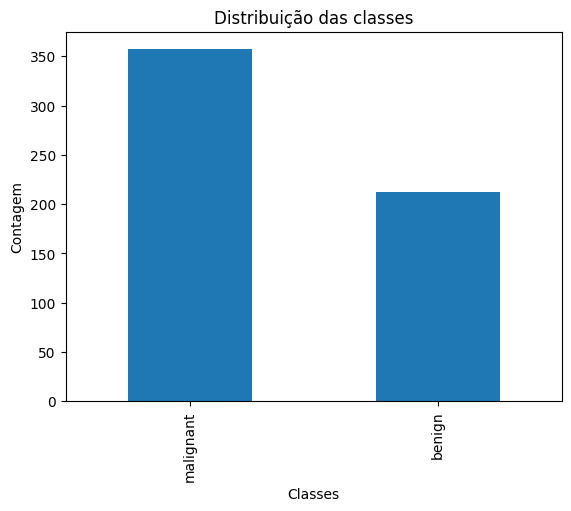

In [92]:
# Gráfico explorando os dados
import matplotlib.pyplot as plt

df_breast_cancer["target"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes")
plt.xlabel("Classes") 
plt.ylabel("Contagem")
plt.xticks(ticks=[0, 1], labels=data_breast_cancer.target_names)
plt.show()


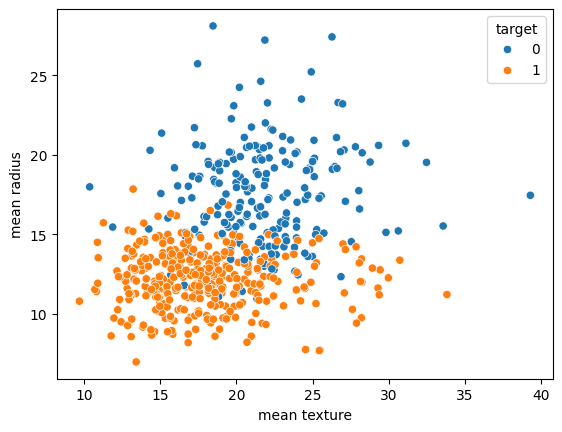

In [93]:
# Gráfico explorando a relação entre duas features e a classe (mean texture vs mean radius)
import seaborn as sns

sns.scatterplot(
    data=df_breast_cancer,
    x="mean texture",
    y="mean radius",
    hue="target"
)

plt.show()

## Pré-processamento

In [94]:

from sklearn.model_selection import train_test_split

X = df_breast_cancer.drop("target", axis=1)
y = df_breast_cancer["target"]

# Separando em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostra a média antes do escalonamento
print("Média antes do escalonamento:\n", X_train.mean())

Média antes do escalonamento:
 mean radius                 14.117635
mean texture                19.185033
mean perimeter              91.882242
mean area                  654.377582
mean smoothness              0.095744
mean compactness             0.103619
mean concavity               0.088898
mean concave points          0.048280
mean symmetry                0.181099
mean fractal dimension       0.062757
radius error                 0.402016
texture error                1.202687
perimeter error              2.858253
area error                  40.071299
smoothness error             0.006989
compactness error            0.025635
concavity error              0.032824
concave points error         0.011894
symmetry error               0.020574
fractal dimension error      0.003820
worst radius                16.235103
worst texture               25.535692
worst perimeter            107.103121
worst area                 876.987033
worst smoothness             0.131532
worst compactness  

## StandardScaler para KNN
### Explicação:
Como algumas variáveis possuem valores muito maiores que outras, elas poderiam dominar o cálculo da distância. O StandardScaler normaliza os dados para que todas as características tenham média próxima de 0 e desvio padrão próximo de 1.

In [95]:
# StandardScaler para KNN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mostra a média depois do escalonamento
print("Média depois do escalonamento:\n", X_train_scaled.mean(axis=0))

Média depois do escalonamento:
 [-3.16230558e-16 -3.51367287e-17 -1.13218348e-16  3.66983611e-16
 -2.38148939e-16 -4.29448906e-17 -5.95372347e-17  2.22532615e-16
  1.44450996e-16  5.05578485e-16  9.56499837e-17  7.02734574e-17
  2.83045870e-16  6.24652955e-17 -7.80816193e-18 -1.52259158e-16
  2.14724453e-17 -2.14724453e-16 -1.91299967e-16  2.24484656e-16
 -7.02734574e-17 -6.75406007e-16 -2.92806072e-17  1.81539765e-16
 -1.56163239e-17 -2.24972666e-16 -7.61295788e-17 -8.19857003e-17
  5.15338687e-16  2.14724453e-17]


## Testando K de 1 a 20

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = []
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    ks.append(k)
    accuracies.append(accuracy)

# Melhor K encontrado até agora
best_index = accuracies.index(max(accuracies))
best_k = ks[best_index]

print(f"O melhor K é: {best_k}")

O melhor K é: 9


### Gráfico Acurácia × K

#### Melhor K encontrado até agora
O melhor K é: 9 porque é o que apresentou a maior acurácia no conjunto de teste, indicando um bom equilíbrio entre viés e variância.


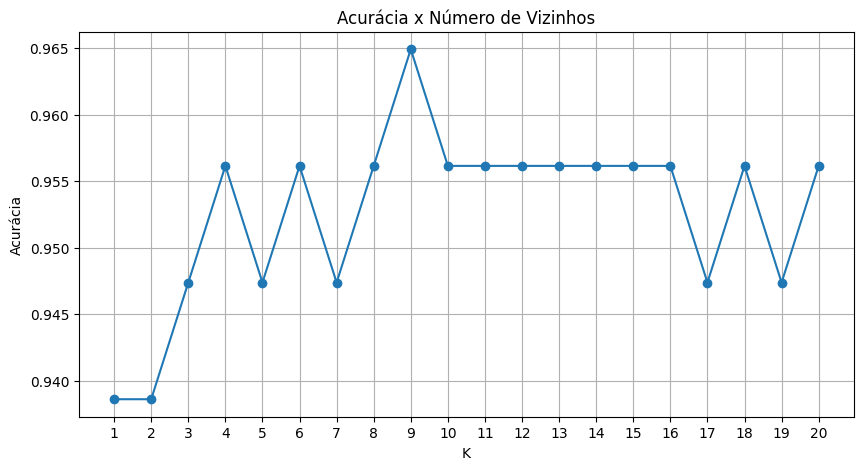

In [97]:
plt.figure(figsize=(10,5))

plt.plot(ks, accuracies, marker="o")

plt.xlabel("K")
plt.ylabel("Acurácia")
plt.title("Acurácia x Número de Vizinhos")
plt.xticks(ks)
plt.grid(True)

plt.show()

## Classification_report do modelo final com o K escolhido

In [101]:
# Modelo final com 9 vizinhos, que apresentou a melhor acurácia melhor no conjunto de teste
from sklearn.metrics import classification_report

final_model = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
final_model.fit(X_train_scaled, y_train)
final_predictions = final_model.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"A acurácia do modelo final com K={best_k} é: {final_accuracy:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, final_predictions))

A acurácia do modelo final com K=9 é: 0.9649

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

